In [187]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error



# You can also use this section to suppress warnings generated by your code:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn
warnings.filterwarnings('ignore')

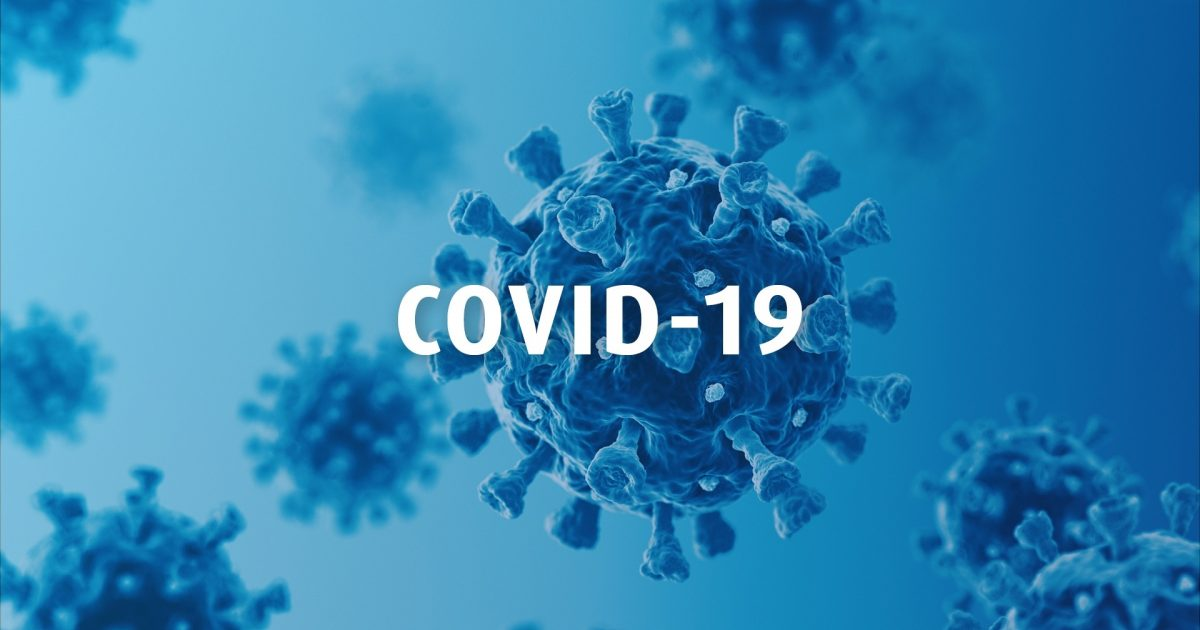

In [11]:
from IPython.display import Image

PATH = "C:/Users/user/Downloads/"
Image(filename = PATH + "Council-COVID-19-Virus.jpg", width=1000, height=1000)

## Problem Statement

This project analyzes COVID-19 infection data for the US, India, and France to identify distinct patterns of transmission dynamics. Using linear regression, the project models infection trends in each country, then identifies the country exhibiting the highest variance in its pattern through cross-validation with the standard deviation of Mean Squared Error. K-means clustering is applied to this country's data, grouping similar periods or regions based on incident rates and infection numbers to reveal distinct clusters. These clusters are characterized to provide insights into varying patterns of COVID-19 spread, leading to conclusions and recommendations for neighboring countries to enhance their public health strategies and pandemic preparedness. By applying data science techniques, this project aims to uncover the underlying patterns of COVID-19 spread and contribute to a better understanding of the pandemic's impact on different regions.

## Libraries for this project



*   [`pandas`](https://pandas.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for managing the data
*   [`Matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for additional plotting tools
*   [`seaborn`](https://seaborn.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for visualizing the data
*   [`sklearn`](https://scikit-learn.org/stable/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for machine learning and machine learning pipeline-related functions.
*   `sklearn.linear_model (LinearRegression):` For building linear regression models.
*   `sklearn.cluster (KMeans):` For performing K-means clustering.
*   `sklearn.metrics (silhouette_score, adjusted_rand_score, mean_squared_error):` For evaluating clustering and regression model performance.
*   `sklearn.preprocessing (StandardScaler):` For data preprocessing, specifically for standardizing features before clustering.
*   `sklearn.model_selection (cross_val_score):` For performing cross-validation to assess model performance.


### 1. EDA

In [2]:
df = pd.read_csv('time_series_covid19_confirmed_global.csv')

In [3]:
df.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,209322,209340,209358,209362,209369,209390,209406,209436,209451,209451
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,334391,334408,334408,334427,334427,334427,334427,334427,334443,334457
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,271441,271448,271463,271469,271469,271477,271477,271490,271494,271496
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,47866,47875,47875,47875,47875,47875,47875,47875,47890,47890
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,105255,105277,105277,105277,105277,105277,105277,105277,105288,105288


In [4]:
df.tail(20)

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
269,Falkland Islands (Malvinas),United Kingdom,-51.796300,-59.523600,0,0,0,0,0,0,...,1930,1930,1930,1930,1930,1930,1930,1930,1930,1930
270,Gibraltar,United Kingdom,36.140800,-5.353600,0,0,0,0,0,0,...,20423,20423,20423,20433,20433,20433,20433,20433,20433,20433
271,Guernsey,United Kingdom,49.448196,-2.589490,0,0,0,0,0,0,...,34867,34929,34929,34929,34929,34929,34929,34929,34991,34991
272,Isle of Man,United Kingdom,54.236100,-4.548100,0,0,0,0,0,0,...,38008,38008,38008,38008,38008,38008,38008,38008,38008,38008
273,Jersey,United Kingdom,49.213800,-2.135800,0,0,0,0,0,0,...,66391,66391,66391,66391,66391,66391,66391,66391,66391,66391
274,Montserrat,United Kingdom,16.742498,-62.187366,0,0,0,0,0,0,...,1403,1403,1403,1403,1403,1403,1403,1403,1403,1403
275,Pitcairn Islands,United Kingdom,-24.376800,-128.324200,0,0,0,0,0,0,...,4,4,4,4,4,4,4,4,4,4
276,"Saint Helena, Ascension and Tristan da Cunha",United Kingdom,-7.946700,-14.355900,0,0,0,0,0,0,...,2166,2166,2166,2166,2166,2166,2166,2166,2166,2166
277,Turks and Caicos Islands,United Kingdom,21.694000,-71.797900,0,0,0,0,0,0,...,6551,6551,6551,6551,6551,6551,6551,6557,6557,6561
278,NaN,United Kingdom,55.378100,-3.436000,0,0,0,0,0,0,...,24370150,24370150,24396530,24396530,24396530,24396530,24396530,24396530,24396530,24425309


In [5]:
# Creating a copy of the original dataframe for late protection
dfc = df.copy()

df.iloc[:,-2]

0      209451
1      334443
2      271494
3       47890
4      105288
        ...  
284    703228
285       535
286     11945
287    343135
288    264276
Name: 3/8/23, Length: 289, dtype: int64

## Algorithm week developement

In [6]:
# Applying a week calculation algorithm for Linear Regression
week = 7 # define a week number
count = 0 # count to be load through a loop
countW = 0 # count to be load through a loop and form the column label
numW = 'Week-' # part of the column label with countW
week_ls = [] # temporarly list for days/week
df_week = pd.DataFrame() # new Dataframe to be stored all the weeks
# df_newly_week = pd.DataFrame() # DataFrame to be stored all the newly week infections day one 14, day two 22 - nwely infected number is 8
no_columsn = df[['Province/State', 'Country/Region', 'Lat', 'Long']]
df_countries = pd.DataFrame()
df = df.drop(columns=['Province/State', 'Country/Region', 'Lat', 'Long'], axis=1)
for i ,j in enumerate(df.columns):
        count += 1
        week_ls.append(df.columns[i])
        if count == week:
            print(week_ls)
            countW += 1
            # print('This is a week ' + str(countW))
            # df_week[numW + str(countW)] =  df[week_ls].sum(axis=1) #df[i].sum(axis=1) #df[df.columns[i]]
            df_week[countW] = dfc[week_ls[-1]]#.sum(axis=1)

            
            # df_newly_week[countW] = dfc[week_ls[-1]] - dfc[week_ls[-2]]
            count = 0
            week_ls.clear()# clear the list as it avoids sum all counting columns

['1/22/20', '1/23/20', '1/24/20', '1/25/20', '1/26/20', '1/27/20', '1/28/20']
['1/29/20', '1/30/20', '1/31/20', '2/1/20', '2/2/20', '2/3/20', '2/4/20']
['2/5/20', '2/6/20', '2/7/20', '2/8/20', '2/9/20', '2/10/20', '2/11/20']
['2/12/20', '2/13/20', '2/14/20', '2/15/20', '2/16/20', '2/17/20', '2/18/20']
['2/19/20', '2/20/20', '2/21/20', '2/22/20', '2/23/20', '2/24/20', '2/25/20']
['2/26/20', '2/27/20', '2/28/20', '2/29/20', '3/1/20', '3/2/20', '3/3/20']
['3/4/20', '3/5/20', '3/6/20', '3/7/20', '3/8/20', '3/9/20', '3/10/20']
['3/11/20', '3/12/20', '3/13/20', '3/14/20', '3/15/20', '3/16/20', '3/17/20']
['3/18/20', '3/19/20', '3/20/20', '3/21/20', '3/22/20', '3/23/20', '3/24/20']
['3/25/20', '3/26/20', '3/27/20', '3/28/20', '3/29/20', '3/30/20', '3/31/20']
['4/1/20', '4/2/20', '4/3/20', '4/4/20', '4/5/20', '4/6/20', '4/7/20']
['4/8/20', '4/9/20', '4/10/20', '4/11/20', '4/12/20', '4/13/20', '4/14/20']
['4/15/20', '4/16/20', '4/17/20', '4/18/20', '4/19/20', '4/20/20', '4/21/20']
['4/22/20', '

In [7]:
# testing add the last column to the week dataframe
countW += 1
df_week[countW] = dfc.iloc[:, -1]
df_week

,1,2,3,4,5,6,7,8,9,10,...,155,156,157,158,159,160,161,162,163,164
0,0,0,0,0,5,5,8,26,42,166,...,207866,208009,208289,208545,208721,209036,209181,209322,209436,209451
1,0,0,0,0,0,0,10,55,123,243,...,333995,334064,334113,334167,334211,334264,334336,334391,334427,334457
2,0,0,0,0,1,5,20,60,264,716,...,271262,271292,271354,271378,271399,271409,271428,271441,271490,271496
3,0,0,0,0,0,1,1,39,164,376,...,47781,47781,47820,47839,47850,47860,47866,47866,47875,47890
4,0,0,0,0,0,0,0,0,3,7,...,105095,105095,105184,105184,105184,105184,105184,105255,105277,105288
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284,0,0,0,0,0,0,26,39,59,119,...,703228,703228,703228,703228,703228,703228,703228,703228,703228,703228
285,0,0,0,0,0,0,0,0,0,0,...,535,535,535,535,535,535,535,535,535,535
286,0,0,0,0,0,0,0,0,0,0,...,11945,11945,11945,11945,11945,11945,11945,11945,11945,11945
287,0,0,0,0,0,0,0,0,3,35,...,335980,337780,339502,340763,341690,342317,342782,343012,343135,343135


In [8]:
# This method will concatenate both dataframes (weekly) and demographic_details
def country_Dataframe(df):
    # cdf = pd.DataFrame(df[['Province/State', 'Country/Region', 'Lat', 'Long']])
    cdf = pd.DataFrame(df[['Province/State', 'Country/Region']])# adding the province and country columns
    new_df = pd.concat([cdf, df_week], axis = 1)
    return new_df #.tail(15)# printing the tail()

# This method will return the top countries with the most infected rates.
def find_largest_infected(num, df):
    sum_lc = df.iloc[:, -1]
    top_nfected = df.nlargest(num, sum_lc.name)
    return top_nfected


In [9]:
cdf = country_Dataframe(dfc)

In [116]:
cdf

,Province/State,Country/Region,1,2,3,4,5,6,7,8,...,155,156,157,158,159,160,161,162,163,164
0,NaN,Afghanistan,0,0,0,0,5,5,8,26,...,207866,208009,208289,208545,208721,209036,209181,209322,209436,209451
1,NaN,Albania,0,0,0,0,0,0,10,55,...,333995,334064,334113,334167,334211,334264,334336,334391,334427,334457
2,NaN,Algeria,0,0,0,0,1,5,20,60,...,271262,271292,271354,271378,271399,271409,271428,271441,271490,271496
3,NaN,Andorra,0,0,0,0,0,1,1,39,...,47781,47781,47820,47839,47850,47860,47866,47866,47875,47890
4,NaN,Angola,0,0,0,0,0,0,0,0,...,105095,105095,105184,105184,105184,105184,105184,105255,105277,105288
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284,NaN,West Bank and Gaza,0,0,0,0,0,0,26,39,...,703228,703228,703228,703228,703228,703228,703228,703228,703228,703228
285,NaN,Winter Olympics 2022,0,0,0,0,0,0,0,0,...,535,535,535,535,535,535,535,535,535,535
286,NaN,Yemen,0,0,0,0,0,0,0,0,...,11945,11945,11945,11945,11945,11945,11945,11945,11945,11945
287,NaN,Zambia,0,0,0,0,0,0,0,0,...,335980,337780,339502,340763,341690,342317,342782,343012,343135,343135


In [117]:
# checking if the number are correct - week-dataframe
sd = cdf.loc[cdf['Country/Region'] == 'China']
sd

,Province/State,Country/Region,1,2,3,4,5,6,7,8,...,155,156,157,158,159,160,161,162,163,164
59,Anhui,China,106,480,860,982,989,990,990,990,...,2275,2275,2275,2275,2275,2275,2275,2275,2275,2275
60,Beijing,China,91,228,342,387,400,414,429,456,...,40774,40774,40774,40774,40774,40774,40774,40774,40774,40774
61,Chongqing,China,132,366,505,555,576,576,576,576,...,14715,14715,14715,14715,14715,14715,14715,14715,14715,14715
62,Fujian,China,80,194,267,292,294,296,296,296,...,17122,17122,17122,17122,17122,17122,17122,17122,17122,17122
63,Gansu,China,19,57,86,91,91,91,125,133,...,1742,1742,1742,1742,1742,1742,1742,1742,1742,1742
64,Guangdong,China,207,813,1177,1328,1347,1350,1353,1364,...,103248,103248,103248,103248,103248,103248,103248,103248,103248,103248
65,Guangxi,China,51,139,215,242,252,252,252,253,...,13371,13371,13371,13371,13371,13371,13371,13371,13371,13371
66,Guizhou,China,9,58,127,146,146,146,146,147,...,2534,2534,2534,2534,2534,2534,2534,2534,2534,2534
67,Hainan,China,40,80,144,163,168,168,168,168,...,10483,10483,10483,10483,10483,10483,10483,10483,10483,10483
68,Hebei,China,33,126,239,306,311,318,318,318,...,3292,3292,3292,3292,3292,3292,3292,3292,3292,3292


In [118]:
# Calculate the provinces by countries 

# # Step 1: Find all countries with multiple provinces
country_counts = cdf['Country/Region'].value_counts()
multi_province_countries = country_counts[country_counts > 1].index

# # Step 2: Initialize a list to store aggregated country rows
aggregated_rows = []

# # Step 3: Loop through each country with multiple provinces
for country in multi_province_countries:
#     # Filter the country's records and drop identifier columns
    country_df = cdf[cdf['Country/Region'] == country].drop(columns=['Province/State', 'Country/Region'])

#     # Sum numeric columns
    country_sum = country_df.sum(numeric_only=True)

#     # Create a new row with 'All' province and the country name
    row_data = {'Province/State': 'All', 'Country/Region': country}
    for col in country_sum.index:
        row_data[col] = country_sum[col]

#     # Append to the list
    aggregated_rows.append(row_data)

# # Step 4: Create a DataFrame from aggregated rows
aggregated_df = pd.DataFrame(aggregated_rows)

# # Step 5: Remove original multi-province country rows
new_df = cdf[~cdf['Country/Region'].isin(multi_province_countries)]

# # Step 6: Combine the cleaned DataFrame with the aggregated rows
final_df = pd.concat([new_df, aggregated_df], ignore_index=True)
final_df.tail(10)



,Province/State,Country/Region,1,2,3,4,5,6,7,8,...,155,156,157,158,159,160,161,162,163,164
191,NaN,Zambia,0,0,0,0,0,0,0,0,...,335980,337780,339502,340763,341690,342317,342782,343012,343135,343135
192,NaN,Zimbabwe,0,0,0,0,0,0,0,0,...,259981,259981,261606,261606,262324,263083,263642,263921,264127,264276
193,All,China,5509,23707,44386,74211,77754,80261,80887,81058,...,4818146,4867556,4889691,4903497,4903513,4903517,4903523,4903524,4903524,4903524
194,All,Canada,4,5,9,10,19,51,165,854,...,4530402,4541961,4554857,4564114,4573997,4582530,4593925,4602806,4612219,4617095
195,All,United Kingdom,0,8,15,19,34,189,888,4456,...,24442197,24475895,24492024,24507298,24526807,24549112,24574823,24603373,24629846,24658705
196,All,France,4,6,11,12,14,212,1783,7715,...,39625664,39666044,39697613,39729161,39753017,39775390,39800890,39827175,39854299,39866718
197,All,Australia,5,13,15,15,15,39,107,452,...,11211305,11247412,11274262,11295446,11312904,11330342,11347698,11366361,11385534,11399460
198,All,Netherlands,0,0,0,0,0,38,503,2057,...,8688997,8691382,8693160,8695133,8697673,8700605,8704407,8708982,8712835,8712835
199,All,Denmark,0,0,0,0,0,6,264,1025,...,3442231,3444124,3445304,3446409,3447384,3448354,3449219,3449989,3450757,3451036
200,All,New Zealand,0,0,0,0,0,1,5,12,...,2146258,2165613,2179522,2190095,2198982,2207348,2215578,2224660,2236113,2236114


In [119]:
# Obtaining the top 3 countries for the regression model
top_3 = find_largest_infected(3, final_df)
top_3

,Province/State,Country/Region,1,2,3,4,5,6,7,8,...,155,156,157,158,159,160,161,162,163,164
179,NaN,US,5,11,13,14,16,74,782,6512,...,101399138,101734426,102086966,102362870,102676694,102934224,103198669,103443455,103690910,103802702
75,NaN,India,0,3,3,3,3,5,56,142,...,44681610,44682595,44683430,44684120,44684864,44685601,44686483,44687837,44689919,44690738
196,All,France,4,6,11,12,14,212,1783,7715,...,39625664,39666044,39697613,39729161,39753017,39775390,39800890,39827175,39854299,39866718


In [120]:

# numb = pd.read_csv('combine-datafra.csv')
# top_3.to_csv('top_3.csv', index=False)
# top_c = pd.read_csv('top_3.csv')

### 2. Build a Regression model

In [121]:
top_3

,Province/State,Country/Region,1,2,3,4,5,6,7,8,...,155,156,157,158,159,160,161,162,163,164
179,NaN,US,5,11,13,14,16,74,782,6512,...,101399138,101734426,102086966,102362870,102676694,102934224,103198669,103443455,103690910,103802702
75,NaN,India,0,3,3,3,3,5,56,142,...,44681610,44682595,44683430,44684120,44684864,44685601,44686483,44687837,44689919,44690738
196,All,France,4,6,11,12,14,212,1783,7715,...,39625664,39666044,39697613,39729161,39753017,39775390,39800890,39827175,39854299,39866718


In [122]:
numb = top_3.drop(columns=['Province/State'])
numb

,Country/Region,1,2,3,4,5,6,7,8,9,...,155,156,157,158,159,160,161,162,163,164
179,US,5,11,13,14,16,74,782,6512,56714,...,101399138,101734426,102086966,102362870,102676694,102934224,103198669,103443455,103690910,103802702
75,India,0,3,3,3,3,5,56,142,536,...,44681610,44682595,44683430,44684120,44684864,44685601,44686483,44687837,44689919,44690738
196,France,4,6,11,12,14,212,1783,7715,22372,...,39625664,39666044,39697613,39729161,39753017,39775390,39800890,39827175,39854299,39866718


In [123]:
# Applying a melt pd so that weeks become a single column
topc_melt = numb.melt(id_vars=['Country/Region'],
                     var_name='weekly', value_name='infections')
topc_melt

,Country/Region,weekly,infections
0,US,1,5
1,India,1,0
2,France,1,4
3,US,2,11
4,India,2,3
...,...,...,...
487,India,163,44689919
488,France,163,39854299
489,US,164,103802702
490,India,164,44690738


In [124]:
countries = topc_melt['Country/Region'].unique()
countries.shape



first_c = topc_melt[topc_melt['Country/Region'] == countries[0]]
first_c

second_c = topc_melt[topc_melt['Country/Region'] == countries[1]]
second_c

third_c = topc_melt[topc_melt['Country/Region'] == countries[2]]
# third_c.head(1)

xf = first_c['weekly'].values.reshape(-1,1)
yf = first_c['infections']



xs = second_c['weekly'].values.reshape(-1,1)
ys = second_c['infections']

xt = third_c['weekly'].values.reshape(-1,1)
yt = third_c['infections']

# Build the model
from sklearn.linear_model import LinearRegression
model1 = LinearRegression()
model1.fit(xf, yf)

model2 = LinearRegression()
model2.fit(xs, ys)

model3 = LinearRegression()
model3.fit(xt, yt)


# # Generate a series of predicted values
y_model1 = pd.Series(model1.predict(xf))
y_model2 = pd.Series(model2.predict(xs))
y_model3 = pd.Series(model3.predict(xt))

print('Model 1: ', model1.intercept_, model1.coef_)
print('Model 2: ', model2.intercept_, model2.coef_)
print('Model 3:', model3.intercept_, model3.coef_)


Model 1:  -15181282.780712262 [760753.00199829]
Model 2:  -3769463.639682781 [357000.92194442]
Model 3: -9772491.849693244 [291832.60734292]


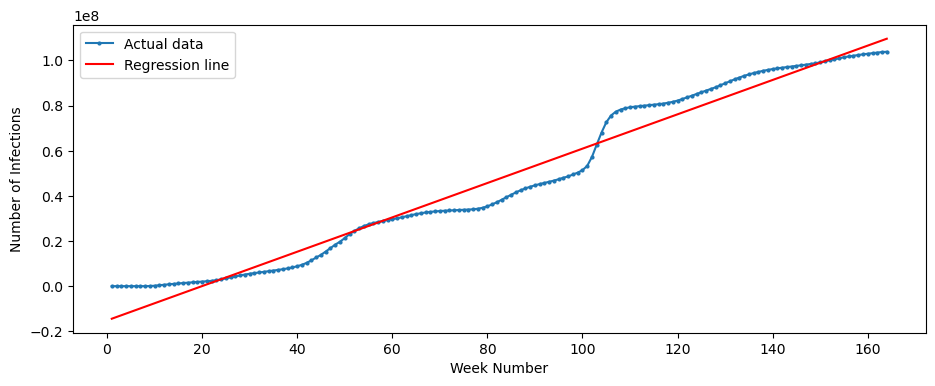

In [125]:
plt.figure(figsize=(11,4))

#plot the data points
plt.plot(xf, yf, marker='o', markersize=2, linestyle='-', label='Actual data')

plt.plot(xf, y_model1, color='red', label='Regression line')
# Add x and y axis labels
plt.xlabel('Week Number')  # Label for the x-axis
plt.ylabel('Number of Infections')  # Label for the y-axis


plt.legend()
plt.show()

The plot for Model 1, representing the US, shows a close alignment between the actual weekly infection data and the fitted regression line. There are four intersections where the actual data crosses the line, and the data is roughly evenly distributed above and below the line. This suggests a relatively strong linear relationship between week number and infections, with the model capturing the overall trend reasonably well.

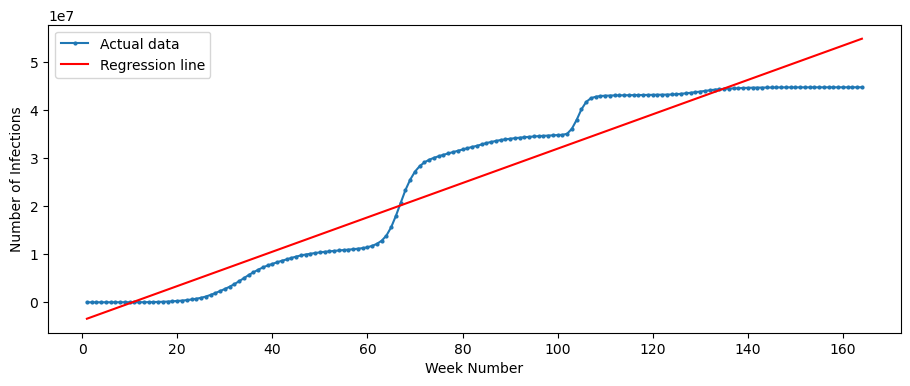

In [126]:
plt.figure(figsize=(11,4))

#plot the data points
plt.plot(xs, ys, marker='o', markersize=2, linestyle='-', label='Actual data')

# Add x and y axis labels
plt.xlabel('Week Number')  # Label for the x-axis
plt.ylabel('Number of Infections')  # Label for the y-axis
plt.plot(xs, y_model2, color='red', label='Regression line')


plt.legend()
plt.show()

The plot for Model 2, representing India, also shows a general upward trend in infections, but with more deviations from the regression line compared to Model 1. There are three intersections, and the data is skewed, with roughly 70% falling below the regression line. This indicates a more complex pattern, with potential dips and resurgences in infection numbers that the model doesn't fully capture

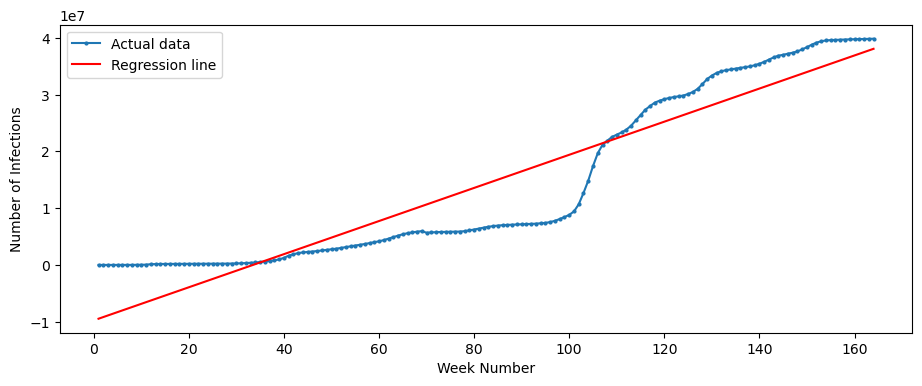

In [127]:
plt.figure(figsize=(11,4))

#plot the data points
plt.plot(xt, yt, marker='o', markersize=2, linestyle='-', label='Actual data')

plt.xlabel('Week Number')  # Label for the x-axis
plt.ylabel('Number of Infections')  # Label for the y-axis
plt.plot(xt, y_model3, color='red', label='Regression line')


plt.legend()
plt.show()

The plot for Model 3, representing France, exhibits the most significant deviations from the regression line. There are only two intersections, and the data is unevenly distributed, with roughly 60% above the line. This suggests a potentially more dynamic and nuanced pattern of infection spread, with periods of acceleration and deceleration that the model might not fully reflect.

In [128]:
# Ensure columns are on a numeric format
topc_melt['weekly'] = pd.to_numeric(topc_melt['weekly'], errors='coerce')
# topc_melt['infections'] = pd.to_numeric(topc_melt['infections'], errors='coerce')

# Drop any rows with NaN values created by the conversion
topc_melt = topc_melt.dropna(subset=['weekly', 'infections'])

In [23]:
topc_melt.dtypes

Country/Region    object
weekly             int64
infections         int64
dtype: object

#### 2.1 Visualization Analysis

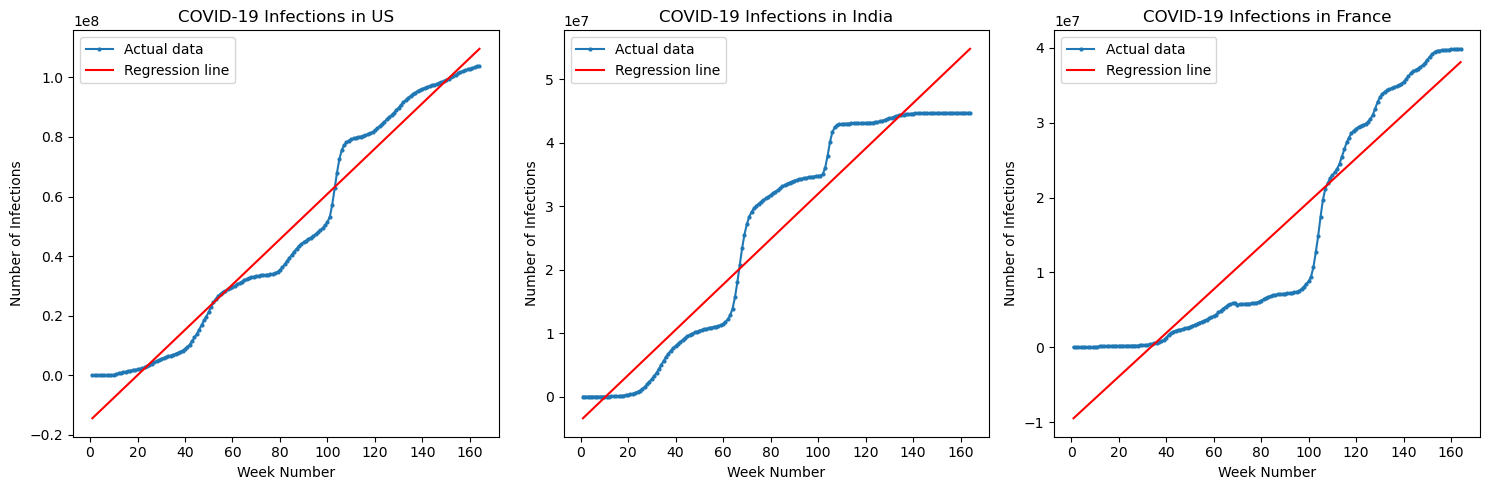

In [184]:
# Assuming you have your data in topc_melt DataFrame
# and countries are ['US', 'India', 'France']

# Create a figure with 3 subplots (one for each country)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # Adjust figsize as needed

# Loop through countries to create each subplot
for i, country in enumerate(countries):
    # Filter data for the current country
    country_data = topc_melt[topc_melt['Country/Region'] == country]

    # Extract x and y values
    x = country_data['weekly'].values.reshape(-1, 1)
    y = country_data['infections']

    # Create and fit the linear regression model
    model = LinearRegression()
    model.fit(x, y)

    # Predict values using the model
    y_pred = model.predict(x)

    # Plot actual data and predicted values on the subplot
    axes[i].plot(x, y, marker='o', markersize=2, linestyle='-', label='Actual data')
    axes[i].plot(x, y_pred, color='red', label='Regression line')

    # Set subplot title and labels
    axes[i].set_title(f'COVID-19 Infections in {country}')
    axes[i].set_xlabel('Week Number')
    axes[i].set_ylabel('Number of Infections')
    axes[i].legend()

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

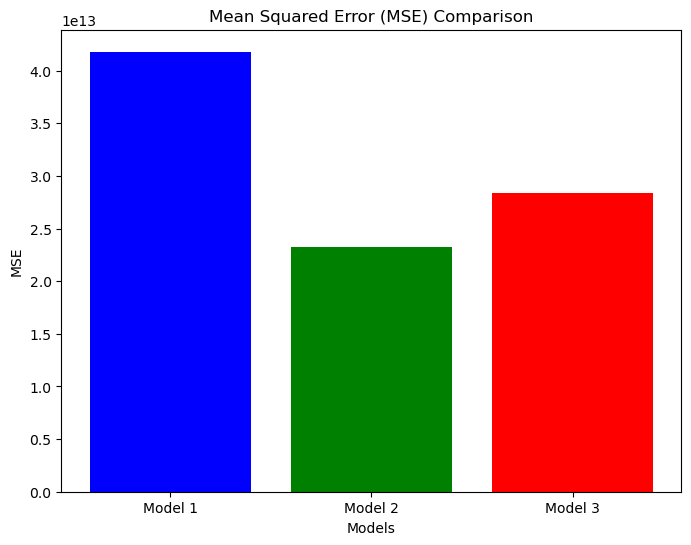

In [130]:
# Calculate MSE for each model
mse_1 = mean_squared_error(yf, y_model1)
mse_2 = mean_squared_error(ys, y_model2)
mse_3 = mean_squared_error(yt, y_model3)

# Model names for the plot
models = ['Model 1', 'Model 2', 'Model 3']
mse_values = [mse_1, mse_2, mse_3]

# Create the bar plot
plt.figure(figsize=(8, 6))
plt.bar(models, mse_values, color=['blue', 'green', 'red'])
plt.title('Mean Squared Error (MSE) Comparison')
plt.xlabel('Models')
plt.ylabel('MSE')
plt.show()

"This bar plot compares the MSE of the three regression models. Model 2, trained on India data, has the lowest MSE, suggesting it is the most accurate. Model 1 (US) and Model 3 (France) have similar high trend of MSEs, indicating comparable performance. These results are crucial for understanding the reliability of our models for forecasting infection trends in different countries."

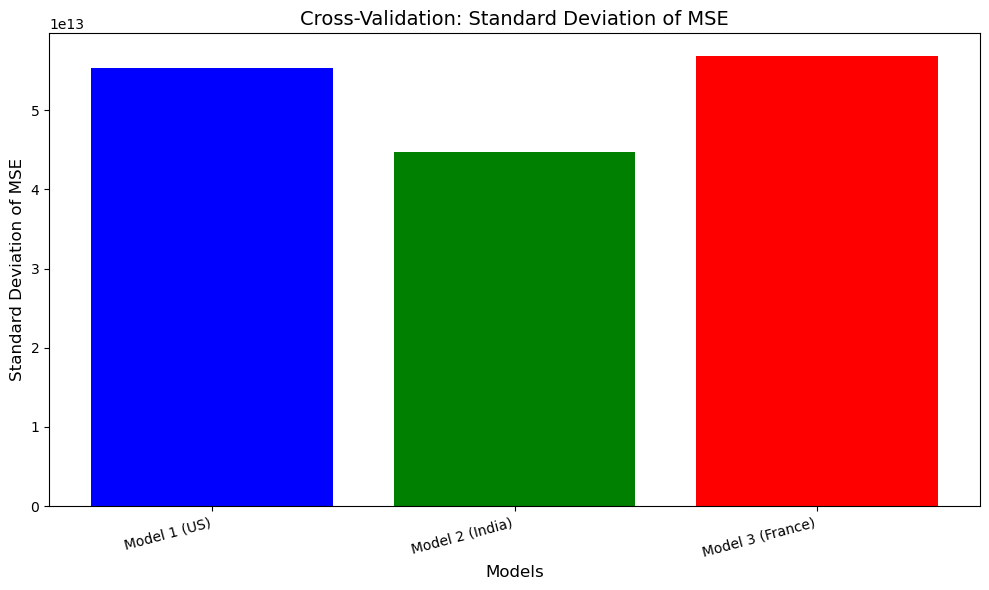

In [180]:
# Cross-Validation with Standard Deviation of Scores Plot:


# Perform cross-validation for each model
cv_scores_1 = cross_val_score(model1, xf, yf, cv=5, scoring='neg_mean_squared_error')
cv_scores_2 = cross_val_score(model2, xs, ys, cv=5, scoring='neg_mean_squared_error')
cv_scores_3 = cross_val_score(model3, xt, yt, cv=5, scoring='neg_mean_squared_error')

# Calculate mean and standard deviation of scores
mean_mse_1 = -np.mean(cv_scores_1)  # Negate to get positive MSE
std_mse_1 = np.std(cv_scores_1)
mean_mse_2 = -np.mean(cv_scores_2)
std_mse_2 = np.std(cv_scores_2)
mean_mse_3 = -np.mean(cv_scores_3)
std_mse_3 = np.std(cv_scores_3)

# Model names and data for the plot
models = ['Model 1 (US)', 'Model 2 (India)', 'Model 3 (France)']  # More descriptive labels
# mean_mse_values = [mean_mse_1, mean_mse_2, mean_mse_3] # Original: Using mean MSE values
std_mse_values = [std_mse_1, std_mse_2, std_mse_3]  # Corrected: Using standard deviation values

# Create the bar plot with error bars
plt.figure(figsize=(10, 6))  # Adjust figure size for better readability
# plt.bar(models, mean_mse_values, yerr=std_mse_values, color=['blue', 'green', 'red'], capsize=5)  # Original: Plotting mean MSE with error bars
plt.bar(models, std_mse_values, color=['blue', 'green', 'red'], capsize=5)  # Corrected: Plotting standard deviation values directly
plt.title('Cross-Validation: Standard Deviation of MSE', fontsize=14)  # Increase title font size
plt.xlabel('Models', fontsize=12)  # Increase x-axis label font size
plt.ylabel('Standard Deviation of MSE', fontsize=12)  # Increase y-axis label font size, corrected label
plt.xticks(rotation=15, ha='right', fontsize=10)  # Rotate x-axis labels for better readability
plt.yticks(fontsize=10)  # Adjust y-axis tick font size

# Applying logarithmic scale to y-axis (optional, if values are very large)
# plt.yscale('log')  

plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

In [182]:
std_mse_values

[55348088883781.05, 44718620558201.23, 56858824767612.2]

When considering the variability in prediction errors (MSE), the model trained on French COVID-19 data (Model 3) exhibits greater fluctuation. This indicates that Model 3 is more responsive to changes in the data and could potentially be more effective at identifying underlying trends and clusters within your dataset compared to the models trained on US (Model 1) and India (Model 2) data.

### 3. Build a Clustering Model

#### 3.1 Processing newly week numbers

In [153]:
# top_3
final_df.tail(10)
no_columsn = final_df[['Province/State', 'Country/Region']]


In [154]:
df_newly_week = pd.DataFrame()
df_newly_week.dtypes

Series([], dtype: object)

In [155]:
# Creating a new df for the newly infect numbers

# drop the label columns 
df2 = final_df.drop(columns=['Province/State', 'Country/Region'], axis=1)
df2 # 193
# cdf = cdf.drop(columns=['Province/State', 'Country/Region'], axis=1)
# Get the column names from df_week
week_columns = df2.columns  
# print(week_columns)
# Get the total number columns
num_weeks = len(week_columns)
# print(num_weeks)

# Calculate and store newly rates for each week
for i in range(num_weeks - 1):  # Iterate through all but the last week
     df_newly_week[i + 1] = df2.iloc[:, i + 1] - df2.iloc[:, i]  # Calculate and assign incident rate

dfkk = pd.concat([no_columsn, df_newly_week], axis = 1)
dfkk.tail(10)





,Province/State,Country/Region,1,2,3,4,5,6,7,8,...,154,155,156,157,158,159,160,161,162,163
191,NaN,Zambia,0,0,0,0,0,0,0,3,...,1285,1800,1722,1261,927,627,465,230,123,0
192,NaN,Zimbabwe,0,0,0,0,0,0,0,3,...,0,0,1625,0,718,759,559,279,206,149
193,All,China,18198,20679,29825,3543,2507,626,171,529,...,156814,49410,22135,13806,16,4,6,1,0,0
194,All,Canada,1,4,1,9,32,114,689,3143,...,22640,11559,12896,9257,9883,8533,11395,8881,9413,4876
195,All,United Kingdom,8,7,4,15,155,699,3568,10683,...,76000,33698,16129,15274,19509,22305,25711,28550,26473,28859
196,All,France,2,5,1,2,198,1571,5932,14657,...,65182,40380,31569,31548,23856,22373,25500,26285,27124,12419
197,All,Australia,8,2,0,0,24,68,345,1592,...,76200,36107,26850,21184,17458,17438,17356,18663,19173,13926
198,All,Netherlands,0,0,0,0,38,465,1554,4375,...,7450,2385,1778,1973,2540,2932,3802,4575,3853,0
199,All,Denmark,0,0,0,0,6,258,761,693,...,4005,1893,1180,1105,975,970,865,770,768,279
200,All,New Zealand,0,0,0,0,1,4,7,143,...,22200,19355,13909,10573,8887,8366,8230,9082,11453,1


In [156]:

# # This method will return the top countries with the most infected rates.
# def find_largest_infected(num, df):
#     sum_lc = df.iloc[:, -2]
#     top_nfected = df.nlargest(num, sum_lc.name)
#     return top_nfected

country = dfkk[dfkk['Country/Region'] == 'France']
country
# new_trend = find_largest_infected(1, dfkk)
# new_trend

,Province/State,Country/Region,1,2,3,4,5,6,7,8,...,154,155,156,157,158,159,160,161,162,163
196,All,France,2,5,1,2,198,1571,5932,14657,...,65182,40380,31569,31548,23856,22373,25500,26285,27124,12419


In [157]:
top_t2 = country.drop(columns=['Province/State'], axis=1)
top_t2

,Country/Region,1,2,3,4,5,6,7,8,9,...,154,155,156,157,158,159,160,161,162,163
196,France,2,5,1,2,198,1571,5932,14657,29909,...,65182,40380,31569,31548,23856,22373,25500,26285,27124,12419


In [158]:
# Applying a melt pd so that weeks become a single column
clutering_1 = top_t2.melt(id_vars=['Country/Region'],
                     var_name='weekly', value_name='newly-inf')
# clutering_1['infections'] = first_c['infections']
clutering_1

,Country/Region,weekly,newly-inf
0,France,1,2
1,France,2,5
2,France,3,1
3,France,4,2
4,France,5,198
...,...,...,...
158,France,159,22373
159,France,160,25500
160,France,161,26285
161,France,162,27124


In [159]:
# calculate the incident rate by manually add the population counting
clutering_1['incident/rate'] =  clutering_1['newly-inf'] / 347276000 # 2025 current population
clutering_1

,Country/Region,weekly,newly-inf,incident/rate
0,France,1,2,5.759108e-09
1,France,2,5,1.439777e-08
2,France,3,1,2.879554e-09
3,France,4,2,5.759108e-09
4,France,5,198,5.701517e-07
...,...,...,...,...
158,France,159,22373,6.442426e-05
159,France,160,25500,7.342863e-05
160,France,161,26285,7.568908e-05
161,France,162,27124,7.810502e-05


In [160]:
# obtain the infections columns from the regression model
clutering_1['infections'] = topc_melt['infections']

# drop the newly-inf which is the newly week infection from the week dataframe
clutering_1 = clutering_1.drop(columns=['newly-inf','Country/Region'], axis=1)
clutering_1

,weekly,incident/rate,infections
0,1,5.759108e-09,5
1,2,1.439777e-08,0
2,3,2.879554e-09,4
3,4,5.759108e-09,11
4,5,5.701517e-07,3
...,...,...,...
158,159,6.442426e-05,3138619
159,160,7.342863e-05,26600309
160,161,7.568908e-05,10777284
161,162,7.810502e-05,3283719


#### 3.2 Visualization the data

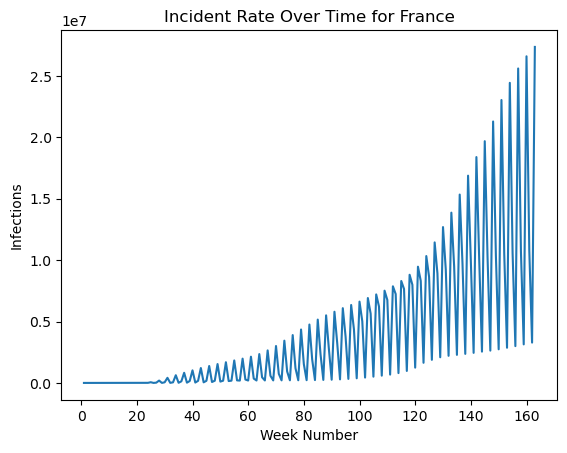

In [161]:
# Line plot of infections over time
plt.plot(clutering_1['weekly'], clutering_1['infections'])
plt.xlabel('Week Number')
plt.ylabel('Infections')
plt.title('Incident Rate Over Time for France')
plt.show()

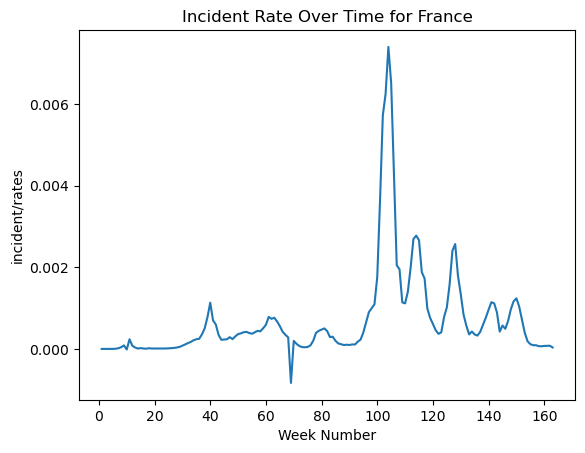

In [162]:
# Line plot of infections over time
plt.plot(clutering_1['weekly'], clutering_1['incident/rate'])
plt.xlabel('Week Number')
plt.ylabel('incident/rates')
plt.title('Incident Rate Over Time for France')
plt.show()

#### 3.3 Clustering - Finding the best K

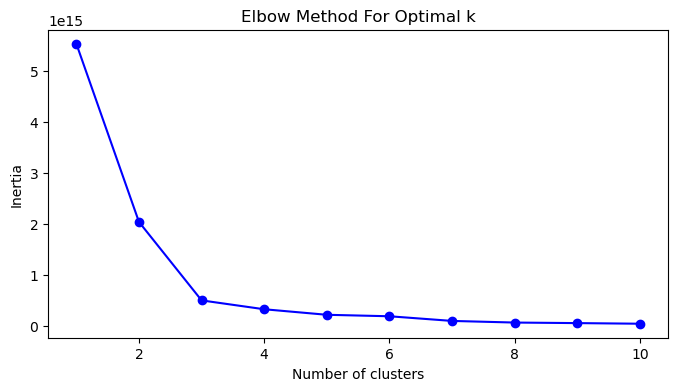

In [176]:



# 1. Select features for clustering 
features = clutering_1[['incident/rate', 'infections']].values

# 2. Standardize the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()

The elbow method is a visual technique to help determine the optimal number of clusters (k) for k-means clustering. The plot shows the WCSS values decreasing as the number of clusters increases. The "elbow" point on the curve represents a good balance between minimizing WCSS and avoiding overfitting.

You would typically choose the value of k where the elbow is most prominent – where the rate of decrease in WCSS starts to slow down significantly. This point suggests that adding more clusters beyond this point doesn't provide much additional benefit in terms of reducing the within-cluster variance.

In this code, the elbow method is used to help you visually identify the best value for k when clustering the COVID-19 data for the US. You would then use this value of k in your KMeans model to perform the actual clustering.

I hope this explanation is helpful! Let me know if you have any more ques

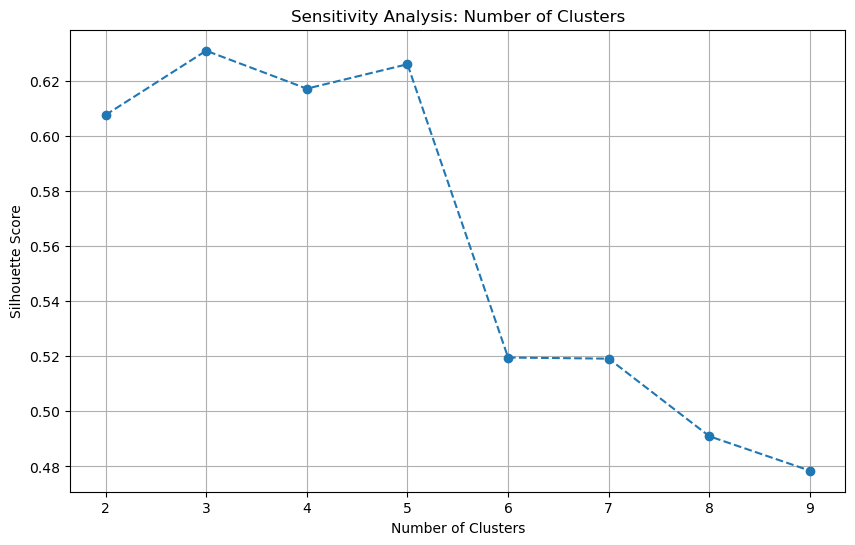

In [166]:

# Sensitivity analysis for number of clusters
cluster_range = range(2, 10)
silhouette_scores = []
cluster_k = []

for n_clusters in cluster_range:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans_labels = kmeans.fit_predict(scaled_features)
    silhouette_avg = silhouette_score(scaled_features, kmeans_labels)
    silhouette_scores.append(silhouette_avg)
    cluster_k.append(['k:', n_clusters, '-', silhouette_avg])

plt.figure(figsize=(10, 6))
plt.plot(cluster_range, silhouette_scores, marker='o', linestyle='--')
plt.title('Sensitivity Analysis: Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

In [167]:
cluster_k

[['k:', 2, '-', 0.6076844832200883],
 ['k:', 3, '-', 0.6310434159264435],
 ['k:', 4, '-', 0.6172623699680965],
 ['k:', 5, '-', 0.6261333704015746],
 ['k:', 6, '-', 0.5195602200391006],
 ['k:', 7, '-', 0.5191484205802261],
 ['k:', 8, '-', 0.4909407360520617],
 ['k:', 9, '-', 0.4784270755624522]]

The sensitivity analysis, utilizing the elbow method and silhouette scores, aimed to determine the optimal number of clusters (k) for K-means clustering. While exploring a range of k values, k=3 emerged as the most promising choice, exhibiting the highest silhouette score of 0.631. This suggests that using three clusters provides the best separation and compactness for the data, indicating a natural grouping into three distinct patterns. Comparing this with k=2, which had a lower silhouette score of 0.608, reinforces the notion that three clusters capture more nuanced variations in the data. Although k=5 achieved a relatively high silhouette score of 0.626, suggesting a reasonable clustering solution, it still fell slightly short of the optimal k=3. This indicates that while five clusters might offer a viable alternative, three clusters are likely to provide a more concise and effective representation of the underlying data structure. Therefore, it is recommended to proceed with k=3 for the K-means clustering analysis to obtain the most meaningful and interpretable results.

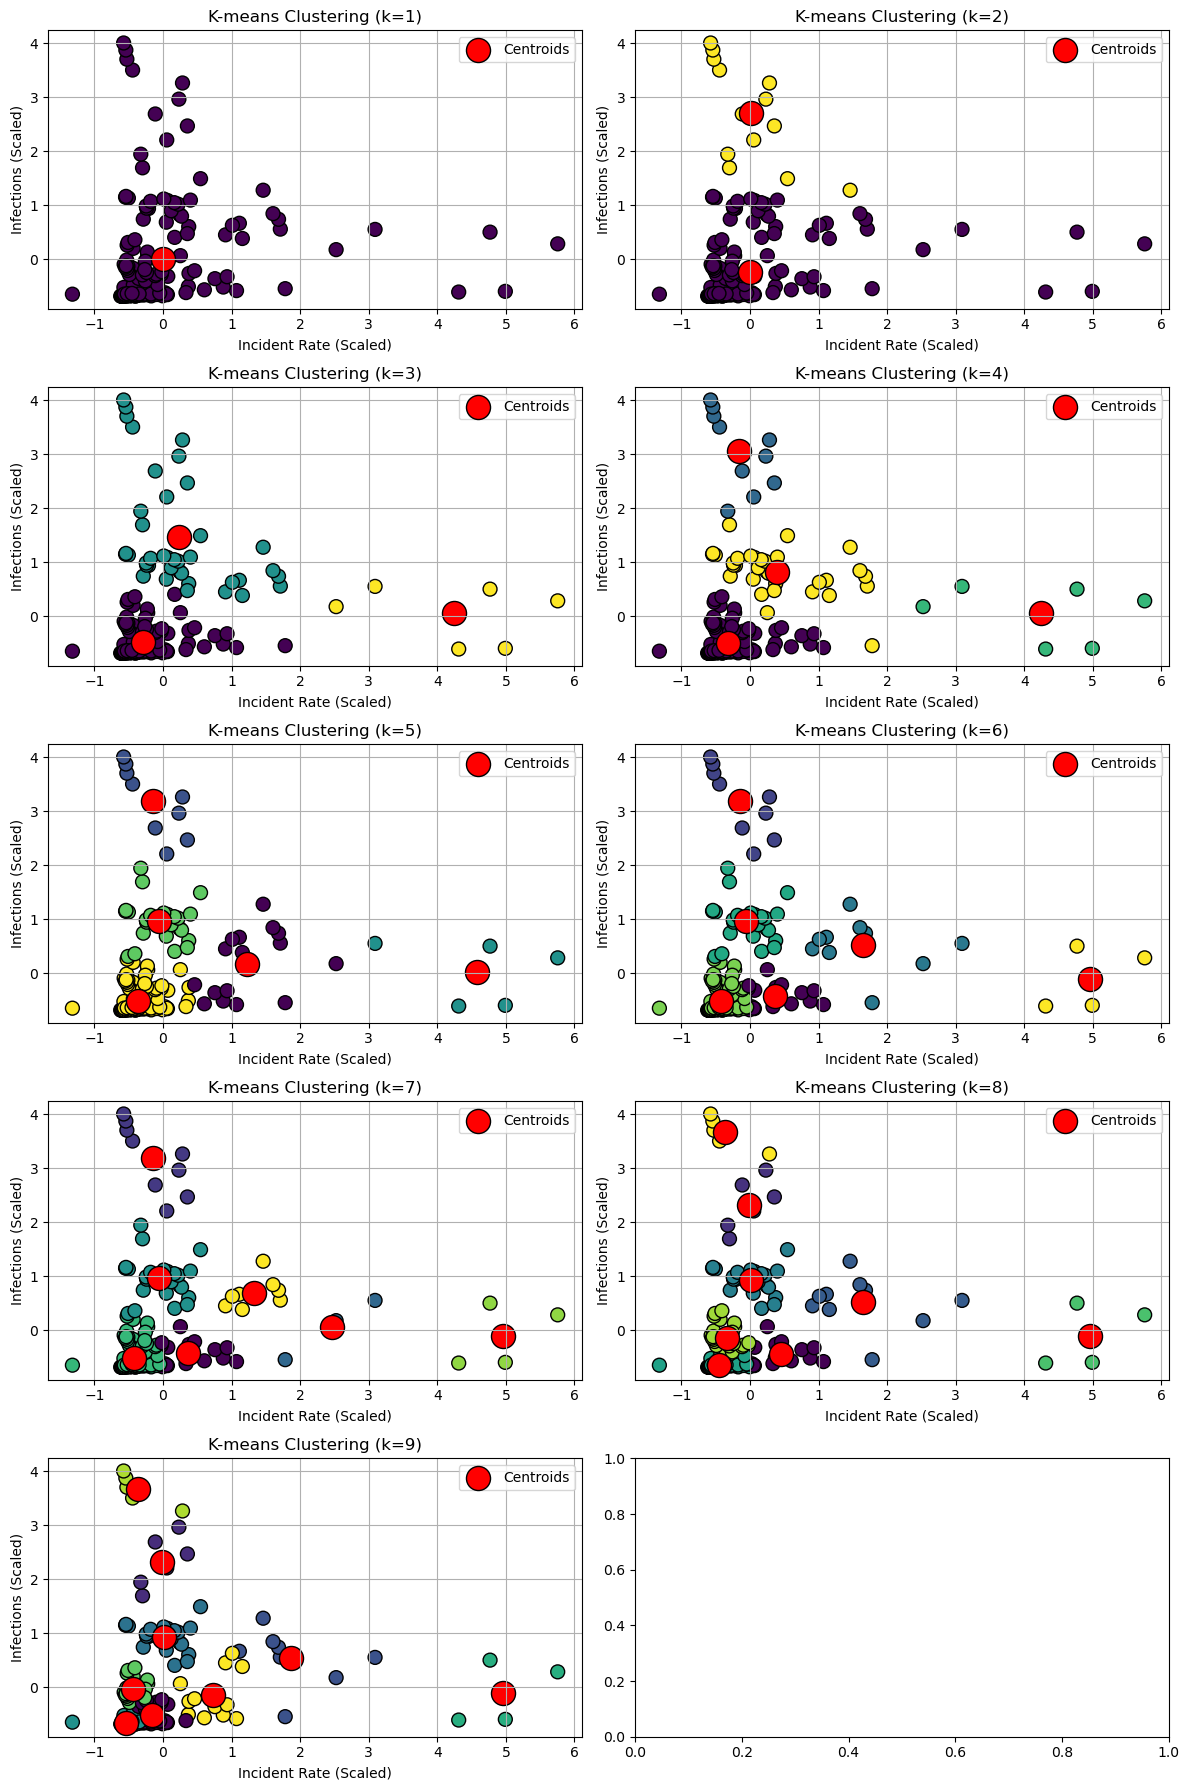

In [168]:
k_range = range(1, 10)  # Range of k values to try

# Create a figure and subplots
fig, axes = plt.subplots(5, 2, figsize=(12, 18))  

# Flatten the axes array for easier iteration
axes = axes.flatten()

for i, k in enumerate(k_range):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    y_kmeans = kmeans.fit_predict(scaled_features) 

    # Plot on the current subplot
    axes[i].scatter(scaled_features[:, 0], scaled_features[:, 1], c=y_kmeans, cmap='viridis', marker='o', edgecolor='k', s=100)
    axes[i].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                s=300, c='red', label='Centroids', edgecolor='k')
    axes[i].set_title(f'K-means Clustering (k={k})')
    axes[i].set_xlabel('Incident Rate (Scaled)') 
    axes[i].set_ylabel('Infections (Scaled)')
    axes[i].legend()
    axes[i].grid()

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

In [170]:
# K-means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(scaled_features)

# Silhouette score
silhouette_avg = silhouette_score(scaled_features, kmeans_labels)
print(f'Silhouette Score: {silhouette_avg}')


Silhouette Score: 0.6310434159264435


In [171]:
# Add cluster labels to the data
clutering_1['Cluster'] = kmeans_labels

# Calculate descriptive statistics
cluster_stats = clutering_1.groupby('Cluster').agg(['mean', 'median', 'std']).reset_index()
cluster_stats.T


0                1               2
Cluster                            0                1               2
weekly        mean         63.686441       134.102564           103.5
              median            59.5            134.0           103.5
              std          41.463752        17.389947        1.870829
incident/rate mean          0.000367         0.000967        0.005636
              median        0.000237         0.000842        0.005985
              std           0.000471         0.000768        0.001416
infections    mean    1166417.118644  12537266.230769       4288569.0
              median        268447.0       10244852.0       5333184.5
              std     1554411.694408   6107846.751646  3063123.816601

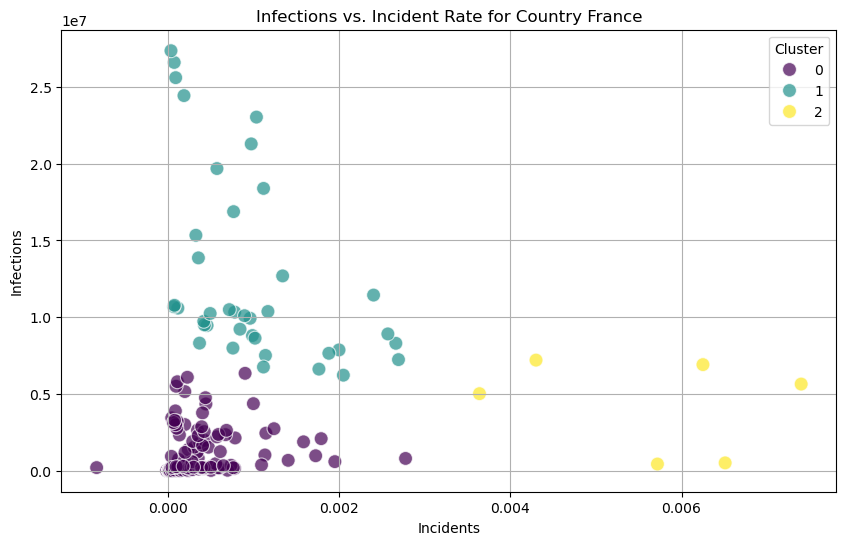

In [186]:
# Visualize clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=clutering_1, x='incident/rate', y='infections', hue='Cluster', palette='viridis', s=100, alpha=0.7)
plt.title('Infections vs. Incident Rate for Country France')
plt.xlabel('Incidents')
plt.ylabel('Infections')
plt.grid(True)
plt.show()

In [174]:
# You can explore the characteristics of each cluster by examining the mean values of the features for each cluster:
print(clutering_1.groupby('Cluster')[['incident/rate', 'infections']].mean())

         incident/rate    infections
Cluster                             
0             0.000367  1.166417e+06
1             0.000967  1.253727e+07
2             0.005636  4.288569e+06


The analysis of the clusters revealed three distinct patterns of COVID-19 spread in France. Cluster 0 is characterized by low numbers of new cases and a low overall infection count, suggesting areas or periods where the virus was effectively contained, possibly due to successful control measures or lower population density. Cluster 1, on the other hand, exhibits a moderate number of new cases but a significantly higher total infection count, indicating wider virus circulation and a larger cumulative impact despite a potentially moderate rate of new infections.

Cluster 2 stands out with the highest rate of new cases but a moderate total infection count. This pattern could indicate a more recent surge in infections, where the number of new cases is rising rapidly but hasn't yet resulted in a high overall infection count like in Cluster 1. These clusters collectively highlight the diverse nature of COVID-19 spread across France, underscoring the importance of considering both the rate of new cases and the overall infection burden when assessing the pandemic's impact and planning public health interventions.

### 4. Graph Analysis